# Notebook 2 - Inflation Divergence and Monetary Policy Response

**Project:** Macro Divergence and Sovereign Bond Value: A Cross-Country Investment Framework  
**Author:** Thomas Sumner  
**Date:** May 2026  

---

## Overview

This notebook addresses three questions:

1. **How and why did inflation diverge across the US, UK and Eurozone after 2020?**
2. **How did central banks respond, and who was most credible?**
3. **What does Japan's structural divergence mean for global sovereign bond markets?**

The findings here directly inform the relative value framework in Notebook 3 and the 
forward-looking rate model in Notebook 4. Central bank credibility differences identified 
here are a primary driver of sovereign bond risk premia across the four markets.

---

## Structure

- **Section 1** - CPI Decomposition: US, UK, Eurozone
- **Section 2** - Taylor Rule: Implied vs Actual Policy Rates
- **Section 3** - Central Bank Credibility Scorecard
- **Section 4** - Inflation Persistence Analysis
- **Section 5** - Japan: Structural Outlier and Global Spillover Risk

---

## Key Investment Question

*Which central banks have successfully re-anchored inflation expectations, and what does 
the answer mean for sovereign bond risk premia today?*

In [31]:
# ============================================================
# Imports and data loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("..")

import fredapi
from dotenv import load_dotenv
import os

load_dotenv()
FRED_API_KEY = os.environ.get("FRED_API_KEY")
fred = fredapi.Fred(api_key=FRED_API_KEY)

START_DATE = "2015-01-01"
END_DATE   = "2026-05-01"

from src.data_loader import (
    load_macro,
    load_ons_monthly,
    load_ecb_hicp,
    load_ecb_unemployment,
    load_imf_output_gap,
    load_market,
    load_boe_nominal,
    load_ecb_aaa_yields,
    load_boe_rate,
    load_yields,
)
# ============================================================
# Load all required datasets
# ============================================================

macro        = load_macro()
ons          = load_ons_monthly()
ecb_hicp     = load_ecb_hicp()
ecb_unemp    = load_ecb_unemployment()
imf_gap      = load_imf_output_gap()
market       = load_market()
boe_nominal  = load_boe_nominal()
ecb_yields   = load_ecb_aaa_yields()
boe_rate     = load_boe_rate()
yields       = load_yields()

# ============================================================
# Chart style — consistent across all notebooks
# ============================================================

NAVY    = "#1f3a5f"
RED     = "#c0392b"
GREEN   = "#27ae60"
AMBER   = "#d4a017"
GREY    = "#7f8c8d"
LGREY   = "#f0f0f0"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.grid":         True,
    "grid.color":        LGREY,
    "grid.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "figure.dpi":        150,
})

print("Imports and data loaded successfully")
print(f"  macro:       {macro.shape}")
print(f"  ons:         {ons.shape}")
print(f"  ecb_hicp:    {ecb_hicp.shape}")
print(f"  ecb_unemp:   {ecb_unemp.shape}")
print(f"  imf_gap:     {imf_gap.shape}")
print(f"  market:      {market.shape}")
print(f"  boe_nominal: {boe_nominal.shape}")
print(f"  ecb_yields:  {ecb_yields.shape}")
print(f"  boe_rate:    {boe_rate.shape}")
print(f"  yields:      {yields.shape}")

Imports and data loaded successfully
  macro:       (136, 12)
  ons:         (135, 4)
  ecb_hicp:    (136, 4)
  ecb_unemp:   (135, 1)
  imf_gap:     (12, 4)
  market:      (4139, 4)
  boe_nominal: (2956, 4)
  ecb_yields:  (2889, 4)
  boe_rate:    (137, 1)
  yields:      (2995, 6)


## Section 1 - CPI Decomposition: US, UK, Eurozone

### Analytical objective
Decompose inflation across the three major economies into headline, core, services and energy 
components. Identify when inflation peaked in each economy, how fast it has fallen, and whether 
services inflation remains sticky. This decomposition explains why inflation diverged and 
provides the input data for the Taylor Rule in Section 2.

### Data
- **US:** Headline CPI and core CPI from FRED. PCE used as cross-check - Fed targets PCE not CPI.
- **UK:** Headline CPI, core CPI and services CPI from ONS.
- **Eurozone:** HICP headline, core, services and energy from ECB - annual rate of change.

### Investment relevance
Sticky services inflation = higher for longer rate path = more duration risk in that market.
The economy with the most persistent services inflation carries the highest reinvestment risk 
for a fixed income investor today.

In [9]:
# ============================================================
# Section 1 — CPI Decomposition
# Build clean inflation DataFrames for US, UK, Eurozone
# All series: year-on-year % change, monthly frequency
# ============================================================

# --- US CPI --- 
# FRED provides index levels — calculate YoY % change
us_cpi = pd.DataFrame({
    "Headline": macro["US_CPI"].pct_change(12) * 100,
    "Core":     macro["US_CPI_CORE"].pct_change(12) * 100,
    "PCE":      macro["US_PCE"].pct_change(12) * 100,
    "PCE_Core": macro["US_PCE_CORE"].pct_change(12) * 100,
}).dropna()

# --- UK CPI ---
# ONS provides index levels — calculate YoY % change
uk_cpi = pd.DataFrame({
    "Headline": ons["UK_CPI"].pct_change(12) * 100,
    "Core":     ons["UK_CPI_CORE"].pct_change(12) * 100,
    "Services": ons["UK_CPI_SERVICES"].pct_change(12) * 100,
}).dropna()

# --- Eurozone HICP ---
# ECB SDW provides annual rate of change directly — no transformation needed
eur_cpi = pd.DataFrame({
    "Headline": ecb_hicp["EUR_HICP_HEADLINE"],
    "Core":     ecb_hicp["EUR_HICP_CORE"],
    "Services": ecb_hicp["EUR_HICP_SERVICES"],
    "Energy":   ecb_hicp["EUR_HICP_ENERGY"],
}).dropna()

# --- Summary statistics ---
print("US CPI — YoY % change")
print(f"  Peak headline: {us_cpi['Headline'].max():.1f}% "
      f"({us_cpi['Headline'].idxmax().strftime('%b %Y')})")
print(f"  Peak core:     {us_cpi['Core'].max():.1f}% "
      f"({us_cpi['Core'].idxmax().strftime('%b %Y')})")
print(f"  Latest headline: {us_cpi['Headline'].iloc[-1]:.1f}% "
      f"({us_cpi.index[-1].strftime('%b %Y')})")
print(f"  Latest core:     {us_cpi['Core'].iloc[-1]:.1f}% "
      f"({us_cpi.index[-1].strftime('%b %Y')})")

print("\nUK CPI — YoY % change")
print(f"  Peak headline: {uk_cpi['Headline'].max():.1f}% "
      f"({uk_cpi['Headline'].idxmax().strftime('%b %Y')})")
print(f"  Peak core:     {uk_cpi['Core'].max():.1f}% "
      f"({uk_cpi['Core'].idxmax().strftime('%b %Y')})")
print(f"  Peak services: {uk_cpi['Services'].max():.1f}% "
      f"({uk_cpi['Services'].idxmax().strftime('%b %Y')})")
print(f"  Latest headline: {uk_cpi['Headline'].iloc[-1]:.1f}% "
      f"({uk_cpi.index[-1].strftime('%b %Y')})")
print(f"  Latest core:     {uk_cpi['Core'].iloc[-1]:.1f}% "
      f"({uk_cpi.index[-1].strftime('%b %Y')})")
print(f"  Latest services: {uk_cpi['Services'].iloc[-1]:.1f}% "
      f"({uk_cpi.index[-1].strftime('%b %Y')})")

print("\nEurozone HICP — YoY % change")
print(f"  Peak headline: {eur_cpi['Headline'].max():.1f}% "
      f"({eur_cpi['Headline'].idxmax().strftime('%b %Y')})")
print(f"  Peak core:     {eur_cpi['Core'].max():.1f}% "
      f"({eur_cpi['Core'].idxmax().strftime('%b %Y')})")
print(f"  Peak services: {eur_cpi['Services'].max():.1f}% "
      f"({eur_cpi['Services'].idxmax().strftime('%b %Y')})")
print(f"  Latest headline: {eur_cpi['Headline'].iloc[-1]:.1f}% "
      f"({eur_cpi.index[-1].strftime('%b %Y')})")
print(f"  Latest core:     {eur_cpi['Core'].iloc[-1]:.1f}% "
      f"({eur_cpi.index[-1].strftime('%b %Y')})")
print(f"  Latest services: {eur_cpi['Services'].iloc[-1]:.1f}% "
      f"({eur_cpi.index[-1].strftime('%b %Y')})")

US CPI — YoY % change
  Peak headline: 9.0% (Jun 2022)
  Peak core:     6.6% (Sep 2022)
  Latest headline: 3.1% (Apr 2026)
  Latest core:     2.4% (Apr 2026)

UK CPI — YoY % change
  Peak headline: 11.1% (Oct 2022)
  Peak core:     7.1% (May 2023)
  Peak services: 7.5% (Jul 2023)
  Latest headline: 3.3% (Mar 2026)
  Latest core:     3.1% (Mar 2026)
  Latest services: 4.5% (Mar 2026)

Eurozone HICP — YoY % change
  Peak headline: 10.6% (Oct 2022)
  Peak core:     5.7% (Mar 2023)
  Peak services: 5.6% (Jul 2023)
  Latest headline: 3.0% (Apr 2026)
  Latest core:     2.2% (Apr 2026)
  Latest services: 3.0% (Apr 2026)


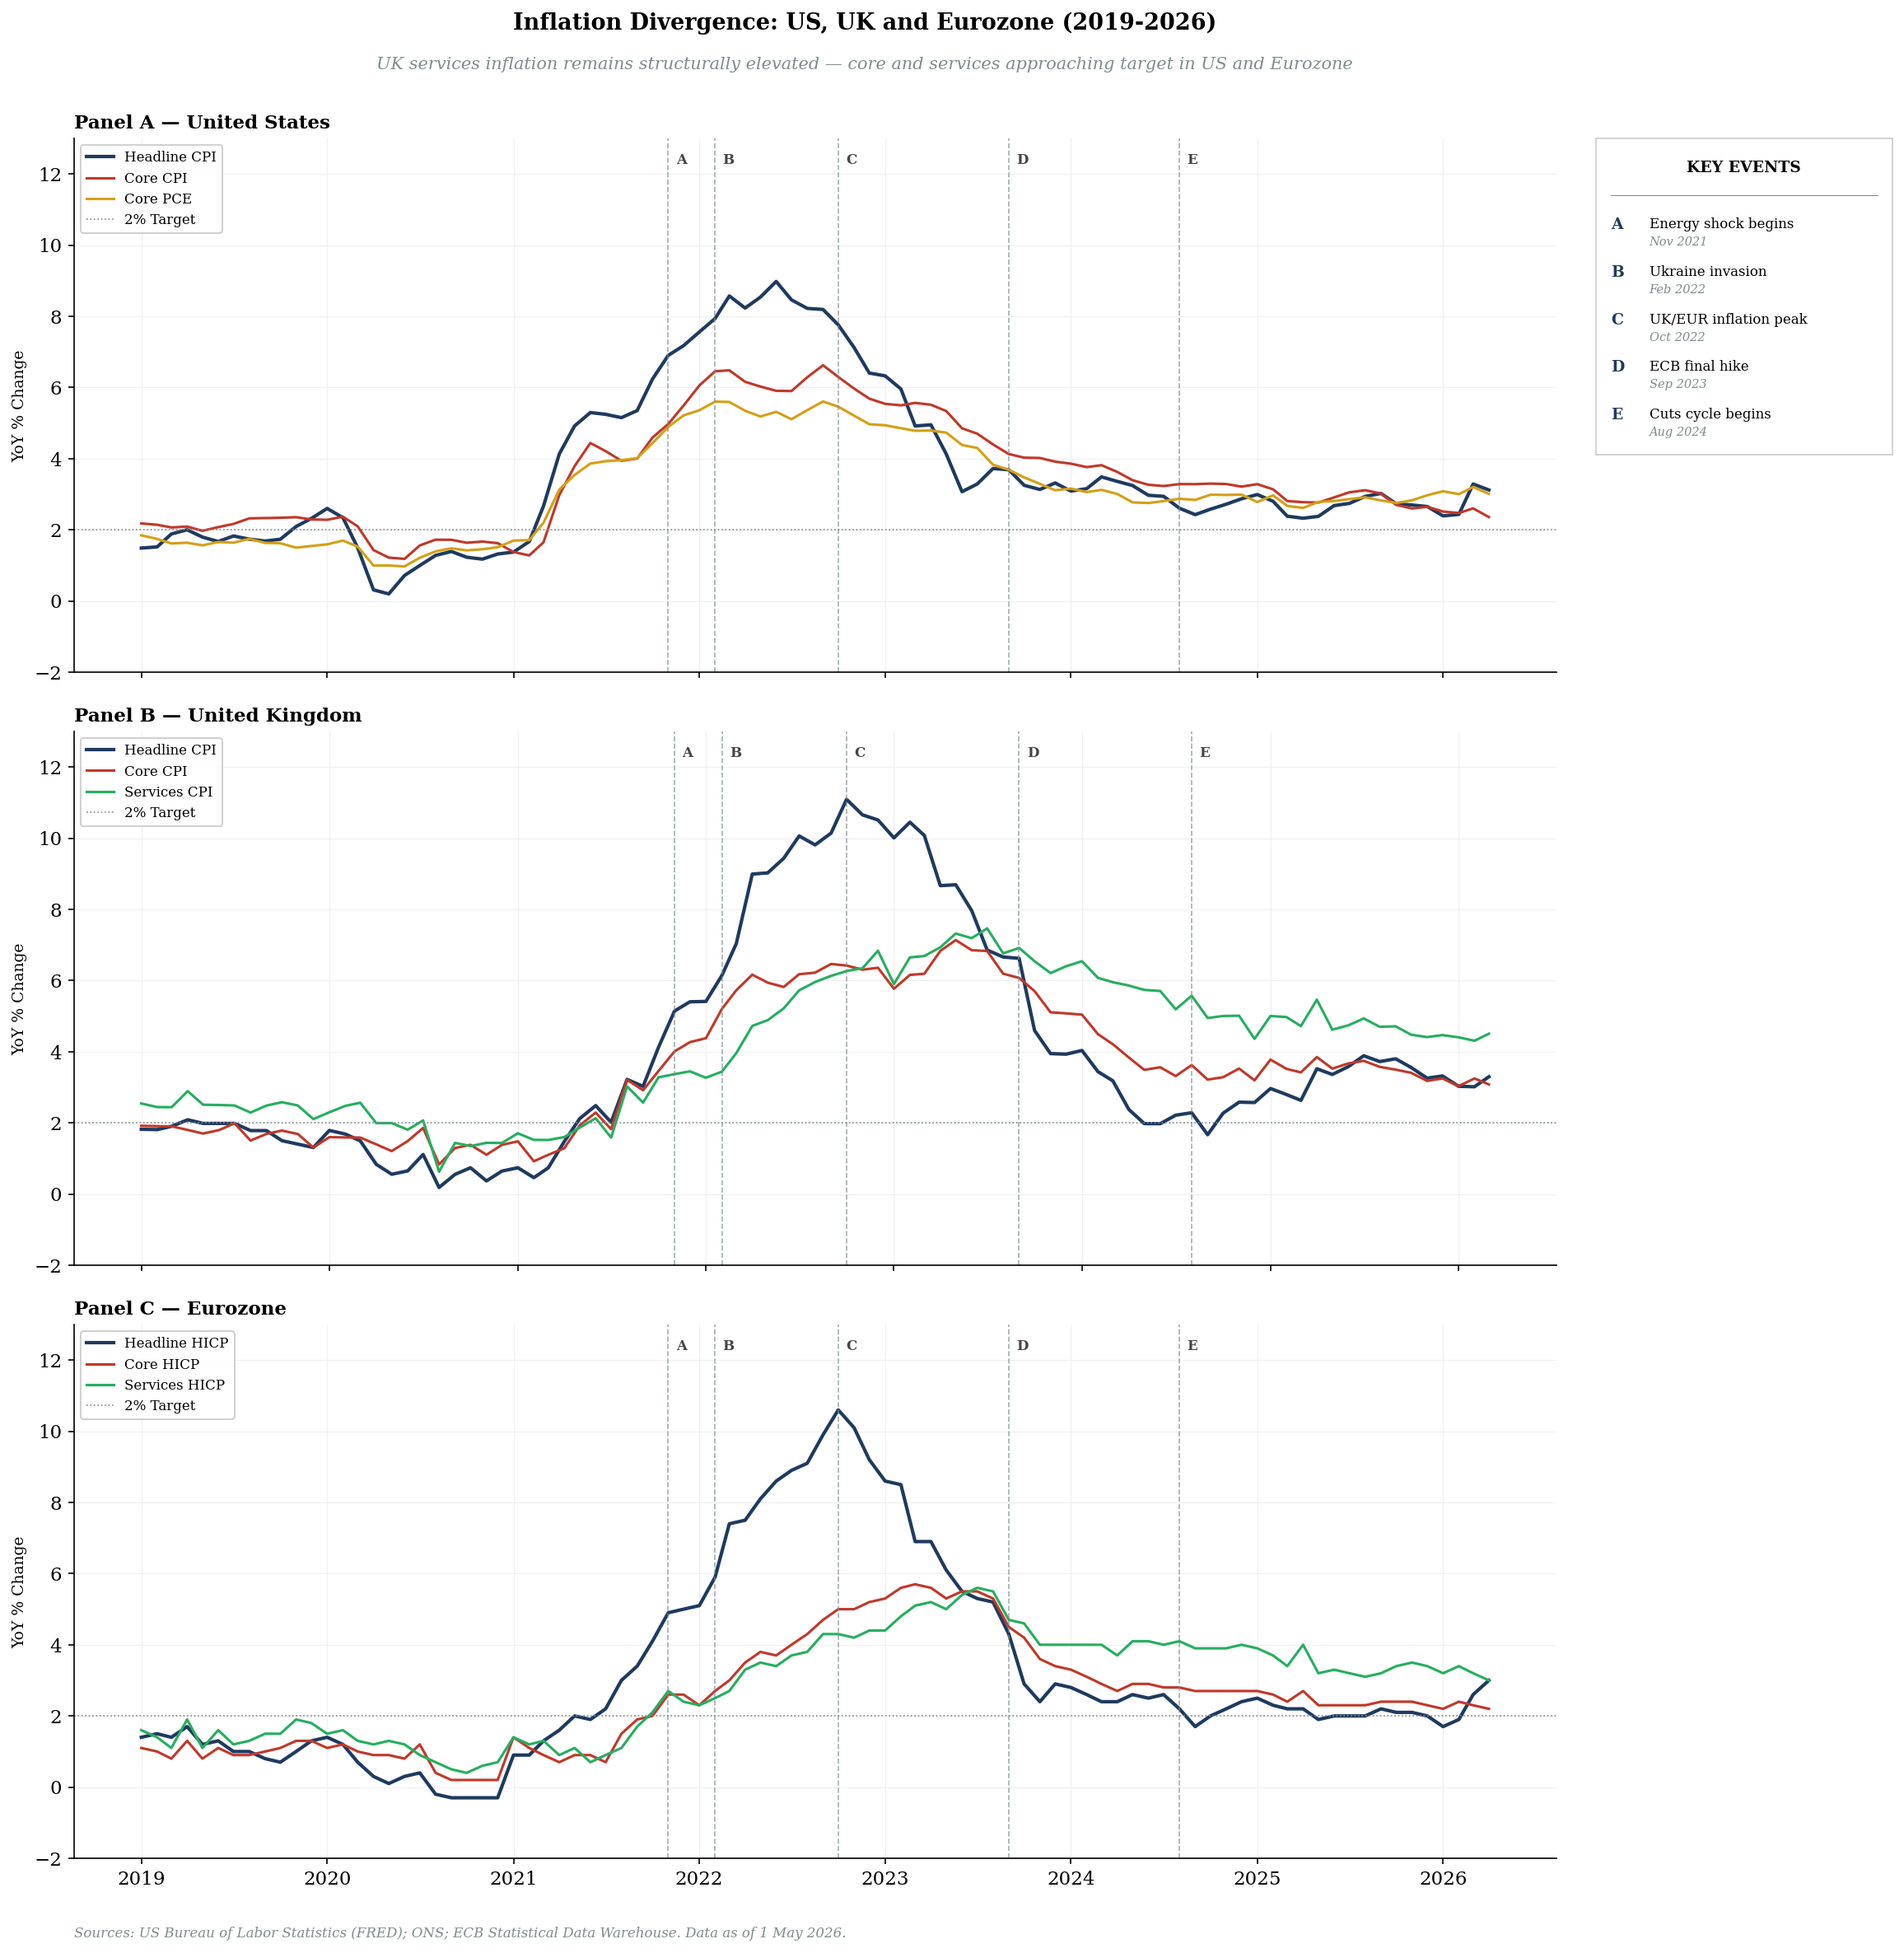

Chart 1 saved — final version


In [14]:
# ============================================================
# Chart 1 — CPI Decomposition: US, UK, Eurozone (Final Version)
# ============================================================

FOCUS_START = "2019-01-01"

us_plot  = us_cpi[us_cpi.index >= FOCUS_START].copy()
uk_plot  = uk_cpi[uk_cpi.index >= FOCUS_START].copy()
eur_plot = eur_cpi[eur_cpi.index >= FOCUS_START].copy()

EVENTS = [
    ("A", pd.Timestamp("2021-11-01"), "Energy shock begins"),
    ("B", pd.Timestamp("2022-02-01"), "Ukraine invasion"),
    ("C", pd.Timestamp("2022-10-01"), "UK/EUR inflation peak"),
    ("D", pd.Timestamp("2023-09-01"), "ECB final hike"),
    ("E", pd.Timestamp("2024-08-01"), "Cuts cycle begins"),
]

EVENT_LABELS = [
    ("A", "Energy shock begins",   "Nov 2021"),
    ("B", "Ukraine invasion",      "Feb 2022"),
    ("C", "UK/EUR inflation peak", "Oct 2022"),
    ("D", "ECB final hike",        "Sep 2023"),
    ("E", "Cuts cycle begins",     "Aug 2024"),
]

fig = plt.figure(figsize=(16, 16))

# Title and subtitle
fig.text(0.45, 0.975,
         "Inflation Divergence: US, UK and Eurozone (2019-2026)",
         fontsize=13, fontweight="bold", ha="center")
fig.text(0.45, 0.955,
         "UK services inflation remains structurally elevated — "
         "core and services approaching target in US and Eurozone",
         fontsize=10, ha="center", color=GREY, style="italic")

# Three chart panels — leave right margin for KEY EVENTS box
ax1 = fig.add_axes([0.05, 0.65, 0.75, 0.27])
ax2 = fig.add_axes([0.05, 0.35, 0.75, 0.27])
ax3 = fig.add_axes([0.05, 0.05, 0.75, 0.27])

# KEY EVENTS box — right side, compact, top aligned with ax1
ax_events = fig.add_axes([0.82, 0.76, 0.15, 0.16])

axes_data = [
    (ax1, us_plot,  "Panel A — United States",
     [("Headline CPI", "Headline", NAVY,  2.0),
      ("Core CPI",     "Core",     RED,   1.5),
      ("Core PCE",     "PCE_Core", AMBER, 1.5)]),
    (ax2, uk_plot,  "Panel B — United Kingdom",
     [("Headline CPI", "Headline", NAVY,  2.0),
      ("Core CPI",     "Core",     RED,   1.5),
      ("Services CPI", "Services", GREEN, 1.5)]),
    (ax3, eur_plot, "Panel C — Eurozone",
     [("Headline HICP", "Headline", NAVY,  2.0),
      ("Core HICP",     "Core",     RED,   1.5),
      ("Services HICP", "Services", GREEN, 1.5)]),
]

for ax, df, title, series in axes_data:
    idx = df.index.to_numpy()

    for label, col, colour, lw in series:
        ax.plot(idx, df[col].to_numpy(),
                label=label, color=colour, linewidth=lw)

    ax.axhline(2.0, color=GREY, linewidth=0.8,
               linestyle=":", label="2% Target")

    for letter, date, _ in EVENTS:
        ax.axvline(date, color=GREY, linewidth=0.8,
                   linestyle="--", alpha=0.7)
        ax.text(date + pd.Timedelta(days=15), 12.3,
                letter, fontsize=8, ha="left",
                color="#444444", fontweight="bold")

    ax.set_title(title, fontweight="bold", fontsize=11,
                 loc="left", pad=6)
    ax.set_ylabel("YoY % Change", fontsize=9)
    ax.set_ylim(-2, 13)
    ax.legend(loc="upper left", framealpha=0.9,
              fontsize=8, ncol=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, color=LGREY, linewidth=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

for ax in [ax1, ax2]:
    ax.set_xticklabels([])

# --- KEY EVENTS panel — compact box, top right ---
ax_events.set_xlim(0, 1)
ax_events.set_ylim(0, 1)
ax_events.set_xticks([])
ax_events.set_yticks([])

for spine in ax_events.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("#cccccc")

ax_events.text(0.5, 0.93, "KEY EVENTS",
               fontsize=9, fontweight="bold",
               ha="center", va="top",
               transform=ax_events.transAxes)

ax_events.axhline(y=0.82, color=GREY,
                  linewidth=0.5, xmin=0.05, xmax=0.95)

spacing = 0.15
for i, (letter, event, date) in enumerate(EVENT_LABELS):
    y = 0.75 - i * spacing
    ax_events.text(0.05, y, f"{letter}",
                   fontsize=9, fontweight="bold",
                   color=NAVY, va="top",
                   transform=ax_events.transAxes)
    ax_events.text(0.18, y, f"{event}",
                   fontsize=8, va="top",
                   transform=ax_events.transAxes)
    ax_events.text(0.18, y - 0.06, date,
                   fontsize=7, color=GREY,
                   style="italic", va="top",
                   transform=ax_events.transAxes)

# Source attribution
fig.text(0.05, 0.01,
         "Sources: US Bureau of Labor Statistics (FRED); "
         "ONS; ECB Statistical Data Warehouse. "
         "Data as of 1 May 2026.",
         fontsize=8, color=GREY, style="italic")

plt.savefig("../charts/chart1_cpi_decomposition.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Chart 1 saved — final version")

### Section 1b - Disinflation Speed

How fast has inflation fallen from its peak across the three economies?
Measured as monthly rate of decline from peak to latest observation.
Cross-country comparison directly informs the relative rate path outlook.

In [16]:
# ============================================================
# Section 1b — Disinflation Speed
# Measures monthly rate of CPI decline from peak to latest
# One measure per economy — central bank's primary concern:
# US: Core PCE (Fed target), UK: Services CPI (BoE focus),
# Eurozone: Services HICP (ECB focus)
# Projection assumes linear continuation — acknowledged 
# simplification, disinflation typically slows near target
# ============================================================

TARGET_RATE = 2.0

def disinflation_speed(series, label, measure):
    """
    Calculate disinflation speed from peak to latest observation.
    Returns peak, latest, total decline, monthly pace and 
    projected months to reach 2% target at current pace.
    """
    s = series.dropna()
    peak_val    = s.max()
    peak_date   = s.idxmax()
    latest_val  = s.iloc[-1]
    latest_date = s.index[-1]

    months = (latest_date.year - peak_date.year) * 12 + \
             (latest_date.month - peak_date.month)

    total_decline = peak_val - latest_val
    monthly_pace  = total_decline / months if months > 0 else 0

    if monthly_pace > 0 and latest_val > TARGET_RATE:
        mths_to_target = round((latest_val - TARGET_RATE) / monthly_pace)
        target_date    = pd.Timestamp(latest_date) + \
                         pd.DateOffset(months=mths_to_target)
        target_str     = f"{mths_to_target}mths ({target_date.strftime('%b %Y')})"
    elif latest_val <= TARGET_RATE:
        target_str = "At/below target"
    else:
        target_str = "N/A"

    return {
        "Economy":        label,
        "Measure":        measure,
        "Peak":           round(peak_val, 1),
        "Peak Date":      peak_date.strftime("%b %Y"),
        "Latest":         round(latest_val, 1),
        "Latest Date":    latest_date.strftime("%b %Y"),
        "Total Decline":  round(total_decline, 1),
        "Months":         months,
        "Monthly Pace":   round(monthly_pace, 2),
        "To Target":      target_str,
    }

results = [
    disinflation_speed(us_cpi["PCE_Core"],  "US",       "Core PCE"),
    disinflation_speed(uk_cpi["Services"],  "UK",       "Services CPI"),
    disinflation_speed(eur_cpi["Services"], "Eurozone", "Services HICP"),
]

dis_df = pd.DataFrame(results)

print("Disinflation Speed — Peak to Latest\n")
print(f"{'Economy':<10} {'Measure':<16} {'Peak':>6} {'Peak Date':<10} "
      f"{'Latest':>7} {'Latest Date':<12} {'Decline':>8} "
      f"{'Months':>7} {'Pace/mo':>9} {'To Target'}")
print("-" * 105)

for r in results:
    print(f"{r['Economy']:<10} {r['Measure']:<16} "
          f"{r['Peak']:>5.1f}% {r['Peak Date']:<10} "
          f"{r['Latest']:>6.1f}% {r['Latest Date']:<12} "
          f"{r['Total Decline']:>6.1f}pp "
          f"{r['Months']:>7} "
          f"{r['Monthly Pace']:>8.2f}pp "
          f"{r['To Target']}")

print("\nNote: projection assumes current pace of disinflation continues")
print("linearly to target. Disinflation typically slows near target —")
print("projected dates should be interpreted as optimistic estimates.")
print("\nKey finding: UK services CPI not projected to reach 2% target")
print("until Jul 2028 — 16 months later than Eurozone services HICP.")
print("This trajectory supports a higher-for-longer BoE rate path")
print("relative to ECB, with direct implications for UK gilt valuations.")

Disinflation Speed — Peak to Latest

Economy    Measure            Peak Peak Date   Latest Latest Date   Decline  Months   Pace/mo To Target
---------------------------------------------------------------------------------------------------------
US         Core PCE           5.6% Sep 2022      3.0% Apr 2026        2.6pp      43     0.06pp 17mths (Sep 2027)
UK         Services CPI       7.5% Jul 2023      4.5% Mar 2026        3.0pp      32     0.09pp 27mths (Jun 2028)
Eurozone   Services HICP      5.6% Jul 2023      3.0% Apr 2026        2.6pp      33     0.08pp 13mths (May 2027)

Note: projection assumes current pace of disinflation continues
linearly to target. Disinflation typically slows near target —
projected dates should be interpreted as optimistic estimates.

Key finding: UK services CPI not projected to reach 2% target
until Jul 2028 — 16 months later than Eurozone services HICP.
This trajectory supports a higher-for-longer BoE rate path
relative to ECB, with direct implicatio

### Section 1 - Investment Conclusion

UK services inflation projects to target in June 2028 - 13 months later than the Eurozone 
and with an identical disinflation pace. The gap is structural, not cyclical. The BoE faces 
a materially longer last mile than the ECB - implying a shallower, slower cutting cycle and 
higher UK short rates for longer. Tested formally in Section 2.

## Section 2 - Taylor Rule: Implied vs Actual Policy Rates

Standard Taylor (1993) specification. Neutral rates: Fed 2.5%, BoE 2.0%, ECB 1.75% (IMF estimates, 
sensitivity tested ±0.5%). Inflation targets: Fed 2% PCE, BoE 2% CPI, ECB 2% HICP. Output gap: 
IMF WEO April 2026 vintage, interpolated to quarterly frequency.

In [19]:
# ============================================================
# Section 2 — Taylor Rule Construction
# Standard Taylor (1993): r = r* + 0.5*(π - π*) + 0.5*(gap)
# Quarterly frequency — aligned with IMF output gap data
# Neutral rates: US 3.0%, UK 2.0%, EUR 1.75%
# Sources: FOMC SEP median; BoE working papers; 
# ECB Economic Bulletin Issue 1/2025
# US: core PCE, UK: headline CPI and services CPI (dual),
# Eurozone: headline HICP
# Output gap: IMF WEO April 2026 vintage, interpolated quarterly
# ============================================================

NEUTRAL = {"US": 3.0, "UK": 2.0, "EUR": 1.75}
TARGET  = {"US": 2.0, "UK": 2.0, "EUR": 2.0}

# --- Resample inflation to quarterly ---
us_inf_q      = us_cpi["PCE_Core"].resample("QS").mean()
uk_inf_hl_q   = uk_cpi["Headline"].resample("QS").mean()
uk_inf_svc_q  = uk_cpi["Services"].resample("QS").mean()
eur_inf_q     = eur_cpi["Headline"].resample("QS").mean()

# --- Resample policy rates to quarterly ---
us_rate_q  = macro["US_FED_FUNDS"].resample("QS").mean()
uk_rate_q  = boe_rate["UK_BANK_RATE"].resample("QS").mean()
eur_rate_q = market["EUR_ECB_RATE"].resample("QS").mean()

# --- IMF output gap — interpolate to quarterly ---
imf_gap_q = imf_gap.copy()
imf_gap_q = imf_gap_q.resample("QS").interpolate(method="linear")

# --- Taylor Rule function ---
def taylor_rule(inflation, target, output_gap, neutral,
                alpha=0.5, beta=0.5):
    """
    Standard Taylor (1993) rule.
    r = r* + alpha*(inflation - target) + beta*(output_gap)
    alpha = beta = 0.5 — standard specification.
    """
    return neutral + alpha * (inflation - target) + beta * output_gap

SAMPLE_START = "2015-01-01"
SAMPLE_END   = "2026-01-01"

def build_taylor(inf_q, gap_col, neutral, target):
    """
    Align inflation and output gap to common quarterly index.
    Returns Taylor Rule implied rate series.
    """
    common_idx = inf_q.index.intersection(imf_gap_q.index)
    common_idx = common_idx[
        (common_idx >= SAMPLE_START) &
        (common_idx <= SAMPLE_END)
    ]
    inf  = inf_q.reindex(common_idx)
    gap  = imf_gap_q[gap_col].reindex(common_idx)
    return taylor_rule(inf, target, gap, neutral)

# --- Build implied rates ---
us_taylor      = build_taylor(us_inf_q,     "US",      NEUTRAL["US"],  TARGET["US"])
uk_taylor_hl   = build_taylor(uk_inf_hl_q,  "UK",      NEUTRAL["UK"],  TARGET["UK"])
uk_taylor_svc  = build_taylor(uk_inf_svc_q, "UK",      NEUTRAL["UK"],  TARGET["UK"])
eur_taylor     = build_taylor(eur_inf_q,    "Germany", NEUTRAL["EUR"], TARGET["EUR"])

# --- Actual policy rates ---
us_actual  = us_rate_q.reindex(us_taylor.index)
uk_actual  = uk_rate_q.reindex(uk_taylor_hl.index)
eur_actual = eur_rate_q.reindex(eur_taylor.index)

# --- Summary table ---
print("Taylor Rule Summary — latest available quarter\n")
print(f"{'Economy':<12} {'Measure':<20} {'Actual':>8} "
      f"{'Implied':>8} {'Deviation':>10} {'Stance'}")
print("-" * 70)

rows = [
    ("US",       "Core PCE",          us_actual,  us_taylor),
    ("UK",       "Headline CPI",      uk_actual,  uk_taylor_hl),
    ("UK",       "Services CPI",      uk_actual,  uk_taylor_svc),
    ("Eurozone", "Headline HICP",     eur_actual, eur_taylor),
]

for label, measure, actual, implied in rows:
    a = actual.dropna().iloc[-1]
    i = implied.dropna().iloc[-1]
    d = a - i
    stance = "Restrictive" if d > 0.25 else \
             "Loose"       if d < -0.25 else "Neutral"
    print(f"{label:<12} {measure:<20} {a:>8.2f}% "
          f"{i:>8.2f}% {d:>+10.2f}%  {stance}")

print("\nDeviation = Actual minus Taylor Rule implied rate")
print("Positive = policy tighter than Taylor Rule implies")
print("Negative = policy looser than Taylor Rule implies")
print("\nNote: UK shown with both headline CPI and services CPI as inflation")
print("input. Services CPI reflects BoE's primary concern — sticky domestic")
print("price pressures. Range between the two measures the BoE credibility gap.")

Taylor Rule Summary — latest available quarter

Economy      Measure                Actual  Implied  Deviation Stance
----------------------------------------------------------------------
US           Core PCE                 3.64%     3.55%      +0.09%  Neutral
UK           Headline CPI             3.75%     2.10%      +1.65%  Restrictive
UK           Services CPI             3.75%     2.74%      +1.01%  Restrictive
Eurozone     Headline HICP            2.00%     1.34%      +0.66%  Restrictive

Deviation = Actual minus Taylor Rule implied rate
Positive = policy tighter than Taylor Rule implies
Negative = policy looser than Taylor Rule implies

Note: UK shown with both headline CPI and services CPI as inflation
input. Services CPI reflects BoE's primary concern — sticky domestic
price pressures. Range between the two measures the BoE credibility gap.


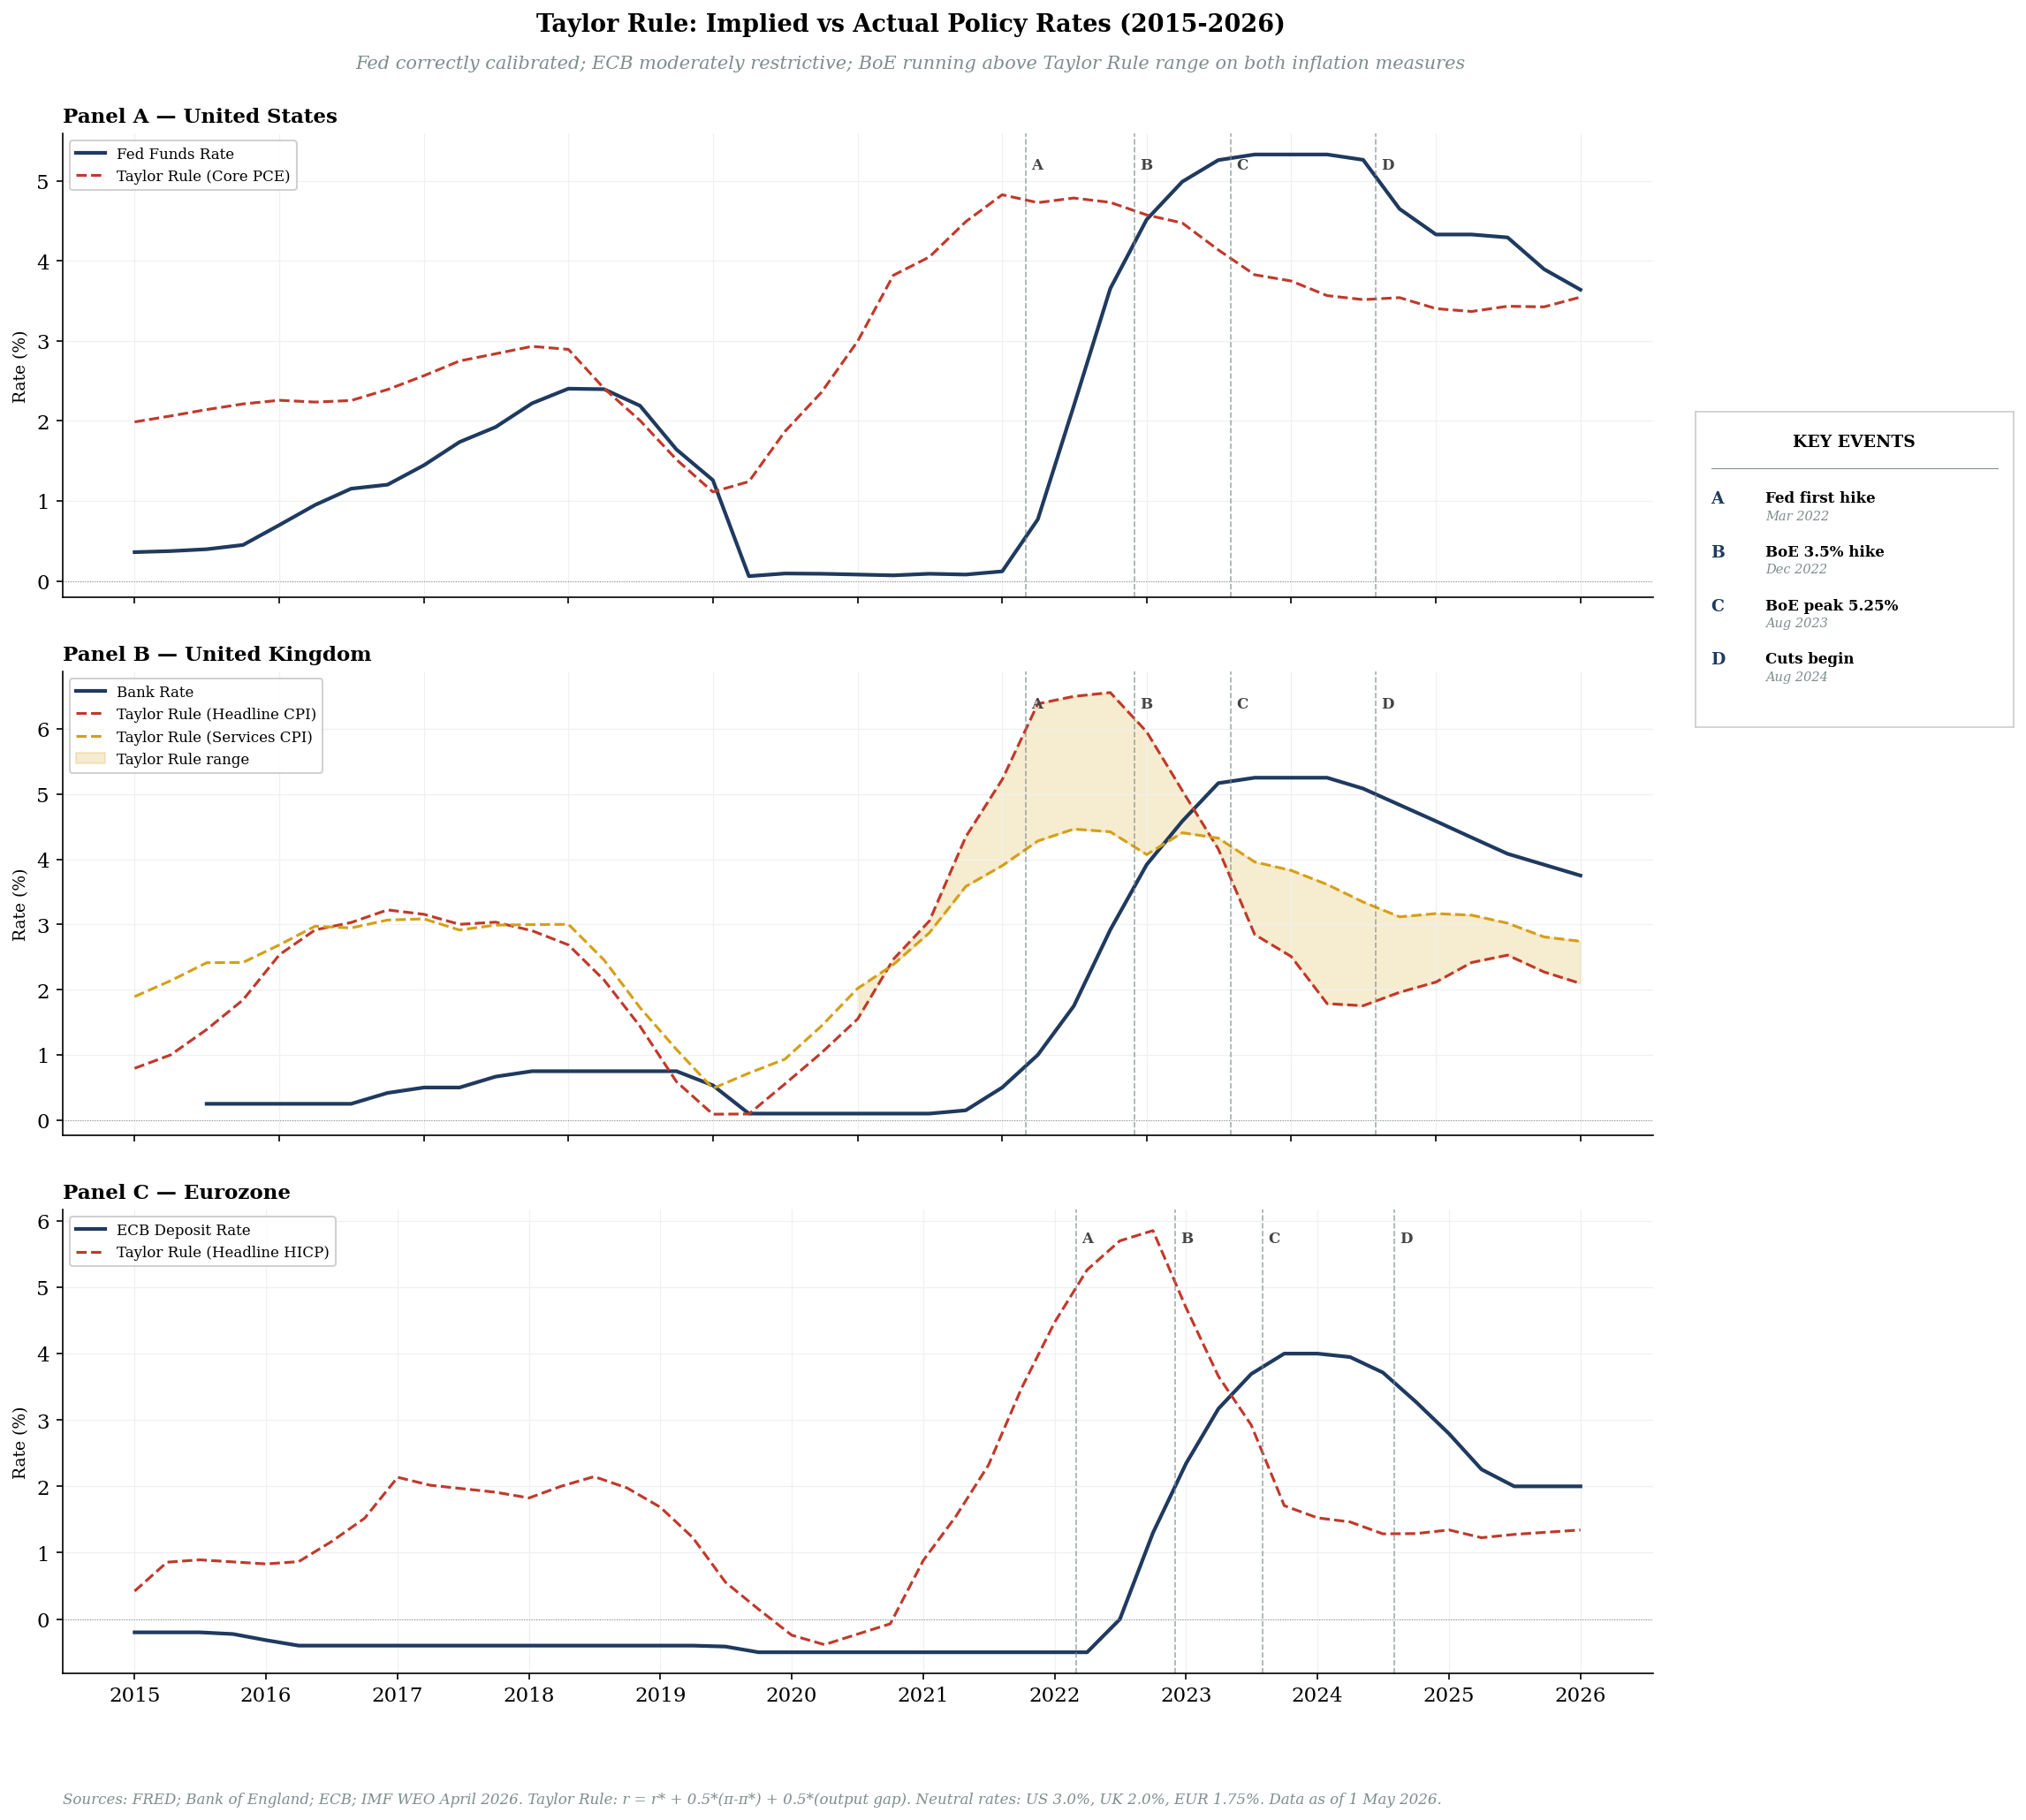

Chart 2 saved — final version


In [22]:
# ============================================================
# Chart 2 — Taylor Rule: Implied vs Actual Policy Rates
# Three panel chart — one per economy
# UK shown with headline and services CPI Taylor Rule range
# Shading from 2021 onwards — policy-relevant period only
# ============================================================

fig = plt.figure(figsize=(16, 14))

fig.text(0.45, 0.975,
         "Taylor Rule: Implied vs Actual Policy Rates (2015-2026)",
         fontsize=13, fontweight="bold", ha="center")
fig.text(0.45, 0.955,
         "Fed correctly calibrated; ECB moderately restrictive; "
         "BoE running above Taylor Rule range on both inflation measures",
         fontsize=10, ha="center", color=GREY, style="italic")

ax1 = fig.add_axes([0.05, 0.67, 0.75, 0.25])
ax2 = fig.add_axes([0.05, 0.38, 0.75, 0.25])
ax3 = fig.add_axes([0.05, 0.09, 0.75, 0.25])
ax_events = fig.add_axes([0.82, 0.60, 0.15, 0.17])

TR_EVENTS = [
    ("A", pd.Timestamp("2022-03-01"), "Fed first hike"),
    ("B", pd.Timestamp("2022-12-01"), "BoE 3.5% hike"),
    ("C", pd.Timestamp("2023-08-01"), "BoE peak 5.25%"),
    ("D", pd.Timestamp("2024-08-01"), "Cuts begin"),
]

TR_EVENT_LABELS = [
    ("A", "Fed first hike",   "Mar 2022"),
    ("B", "BoE 3.5% hike",   "Dec 2022"),
    ("C", "BoE peak 5.25%",  "Aug 2023"),
    ("D", "Cuts begin",       "Aug 2024"),
]

SHADE_START = "2021-01-01"

axes_data = [
    (ax1, "Panel A — United States",
     us_actual, us_taylor, None,
     "Fed Funds Rate", "Taylor Rule (Core PCE)", None),
    (ax2, "Panel B — United Kingdom",
     uk_actual, uk_taylor_hl, uk_taylor_svc,
     "Bank Rate", "Taylor Rule (Headline CPI)", "Taylor Rule (Services CPI)"),
    (ax3, "Panel C — Eurozone",
     eur_actual, eur_taylor, None,
     "ECB Deposit Rate", "Taylor Rule (Headline HICP)", None),
]

for ax, title, actual, implied_low, implied_high, \
        label_actual, label_low, label_high in axes_data:

    # Actual policy rate
    ax.plot(actual.dropna().index.to_numpy(),
            actual.dropna().to_numpy(),
            color=NAVY, linewidth=2.0, label=label_actual)

    # Taylor Rule implied — primary measure
    ax.plot(implied_low.dropna().index.to_numpy(),
            implied_low.dropna().to_numpy(),
            color=RED, linewidth=1.5, linestyle="--",
            label=label_low)

    # UK — services Taylor Rule and shading from 2021 only
    if implied_high is not None:
        ax.plot(implied_high.dropna().index.to_numpy(),
                implied_high.dropna().to_numpy(),
                color=AMBER, linewidth=1.5, linestyle="--",
                label=label_high)

        # Shade only from 2021 onwards
        common = implied_low.dropna().index.intersection(
                 implied_high.dropna().index)
        common = common[common >= SHADE_START]
        ax.fill_between(
            common.to_numpy(),
            implied_low.reindex(common).to_numpy(),
            implied_high.reindex(common).to_numpy(),
            alpha=0.2, color=AMBER,
            label="Taylor Rule range"
        )

    # Zero line
    ax.axhline(0, color=GREY, linewidth=0.5, linestyle=":")

    # Event markers — letter position as fraction of y range
    ymin, ymax = ax.get_ylim()
    letter_y = ymax * 0.92

    for letter, date, _ in TR_EVENTS:
        ax.axvline(date, color=GREY, linewidth=0.8,
                   linestyle="--", alpha=0.7)
        ax.text(date + pd.Timedelta(days=15),
                letter_y, letter,
                fontsize=8, ha="left",
                color="#444444", fontweight="bold")

    ax.set_title(title, fontweight="bold", fontsize=11,
                 loc="left", pad=6)
    ax.set_ylabel("Rate (%)", fontsize=9)
    ax.legend(loc="upper left", framealpha=0.9, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, color=LGREY, linewidth=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

for ax in [ax1, ax2]:
    ax.set_xticklabels([])

# KEY EVENTS box
ax_events.set_xlim(0, 1)
ax_events.set_ylim(0, 1)
ax_events.set_xticks([])
ax_events.set_yticks([])

for spine in ax_events.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("#cccccc")

ax_events.text(0.5, 0.93, "KEY EVENTS",
               fontsize=9, fontweight="bold",
               ha="center", va="top",
               transform=ax_events.transAxes)

ax_events.axhline(y=0.82, color=GREY,
                  linewidth=0.5, xmin=0.05, xmax=0.95)

spacing = 0.17
for i, (letter, event, date) in enumerate(TR_EVENT_LABELS):
    y = 0.75 - i * spacing
    ax_events.text(0.05, y, letter,
                   fontsize=9, fontweight="bold",
                   color=NAVY, va="top",
                   transform=ax_events.transAxes)
    ax_events.text(0.22, y, event,
                   fontsize=8, fontweight="bold",
                   va="top",
                   transform=ax_events.transAxes)
    ax_events.text(0.22, y - 0.06, date,
                   fontsize=7, color=GREY,
                   style="italic", va="top",
                   transform=ax_events.transAxes)

fig.text(0.05, 0.02,
         "Sources: FRED; Bank of England; ECB; IMF WEO April 2026. "
         "Taylor Rule: r = r* + 0.5*(π-π*) + 0.5*(output gap). "
         "Neutral rates: US 3.0%, UK 2.0%, EUR 1.75%. "
         "Data as of 1 May 2026.",
         fontsize=8, color=GREY, style="italic")

plt.savefig("../charts/chart2_taylor_rule.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Chart 2 saved — final version")

### Section 2 - Investment Conclusion

The Fed is essentially neutral relative to the Taylor Rule (+9bps). The ECB is moderately 
restrictive (+66bps) with room to cut further. The BoE is running above its Taylor Rule 
range on both inflation measures (+101-165bps) - a deliberate premium maintaining credibility 
against persistent services inflation.

**Therefore:** The ECB cutting cycle has more room to run than the BoE's. UK short-end rates 
stay higher for longer relative to Eurozone. This relative rate path divergence is the core 
input to the sovereign bond relative value framework in Notebook 3.

## Section 3 - Central Bank Credibility Assessment

The Taylor Rule analysis produces a clear credibility ranking across the three economies.

**Federal Reserve - most credible.** Was behind the curve in 2021-2022 by approximately 
300bps at peak but responded aggressively once hiking began, raising rates by 525bps in 
16 months. Now essentially neutral relative to the Taylor Rule (+9bps). Inflation has fallen 
from 9.0% to 3.1% headline. The Fed's dual mandate complicates comparison but on inflation 
alone the response was ultimately decisive.

**ECB - credibility damaged, recovering.** Was most behind the curve in 2022 - actual rate 
near zero while Taylor Rule implied above 5%, a deviation of approximately 500bps at peak. 
Tightened aggressively but later than peers. Now moderately restrictive (+66bps) with core 
HICP at 2.2% - approaching target. Credibility recovery is well advanced.

**Bank of England - credibility premium.** Peak deviation of approximately 200-300bps in 
2021-2022. Inflation reached 11.1% - highest of the three. Now running above Taylor Rule 
range on both inflation measures (+101-165bps) - a deliberate premium to rebuild credibility 
damaged by the late 2021 response. Services inflation at 4.5% justifies caution but also 
means the BoE cutting cycle will be the most constrained of the three.

**Investment implication:** Markets that trust their central bank require less term premium 
compensation. The Fed's credibility advantage supports tighter Treasury term premia relative 
to gilts. The BoE credibility premium - running tight to rebuild trust - keeps UK short rates 
elevated. This feeds directly into the relative value framework in Notebook 3.

## Section 4 - Japan: Structural Outlier and Global Spillover Risk

Unlike the Fed, BoE and ECB, the BoJ was not attempting to set rates in response to 
inflation and growth. From 2016 it pegged the 10Y JGB yield at an explicit ceiling - 
first 0%, later relaxed to 0.25% then 0.5% - buying unlimited bonds to defend it. 
When Japanese inflation finally broke above 2% in 2022, the Taylor Rule would have 
implied significant hikes. The BoJ held the cap anyway.

The relevant question is not how far behind the curve the BoJ was. It is what the 
unwinding of that peg means for global bond markets, and for investors holding US 
Treasuries and UK gilts.

In [32]:
# ============================================================
# Section 4 — Japan Data Construction
# JGB 10Y and BoJ rate from FRED/macro series
# Rate differentials vs US and UK
# ============================================================

# --- Japan series ---
jpn_jgb   = macro["JPN_JGB_10Y"].dropna()
jpn_rate  = macro["JPN_BOJ_RATE"].dropna()

# --- US and UK 10Y for differential ---
us_10y = yields["US_10Y"].resample("MS").mean().dropna()
uk_10y = boe_nominal["10Y"].resample("MS").mean().dropna()

# --- Japan CPI YoY — limited to Jun 2021, noted as data limitation ---
jpn_cpi_yoy = macro["JPN_CPI"].pct_change(12) * 100

# Current BoJ rate and CPI — cited from official sources
# BoJ rate: 0.50% as of January 2025
# Japan CPI: approximately 3.6% as of early 2026
BOJ_CURRENT_RATE  = 0.50
JAPAN_CPI_CURRENT = 3.6

# --- Rate differentials ---
DIFF_START = "2015-01-01"

common_us = us_10y.index.intersection(jpn_jgb.index)
common_us = common_us[common_us >= DIFF_START]

common_uk = uk_10y.index.intersection(jpn_jgb.index)
common_uk = common_uk[common_uk >= DIFF_START]

us_jgb_diff = us_10y.reindex(common_us) - jpn_jgb.reindex(common_us)
uk_jgb_diff = uk_10y.reindex(common_uk) - jpn_jgb.reindex(common_uk)

print("Japan data summary:\n")
print(f"  JGB 10Y:  {len(jpn_jgb)} obs | "
      f"{jpn_jgb.index.min().date()} to {jpn_jgb.index.max().date()}")
print(f"  BoJ rate: {len(jpn_rate)} obs | "
      f"{jpn_rate.index.min().date()} to {jpn_rate.index.max().date()}")
print(f"  US-JGB differential: {len(us_jgb_diff)} obs")
print(f"  UK-JGB differential: {len(uk_jgb_diff)} obs")

print(f"\nCurrent readings (cited):")
print(f"  BoJ rate:    {BOJ_CURRENT_RATE}% (Jan 2025)")
print(f"  Japan CPI:   {JAPAN_CPI_CURRENT}% (early 2026, Japan Statistics Bureau)")

print(f"\nRate differentials — latest:")
print(f"  US 10Y vs JGB 10Y: {us_jgb_diff.dropna().iloc[-1]:.2f}%")
print(f"  UK 10Y vs JGB 10Y: {uk_jgb_diff.dropna().iloc[-1]:.2f}%")

print(f"\nRate differentials — peak (pre-normalisation):")
print(f"  US 10Y vs JGB 10Y peak: {us_jgb_diff.dropna().max():.2f}% "
      f"({us_jgb_diff.dropna().idxmax().strftime('%b %Y')})")
print(f"  UK 10Y vs JGB 10Y peak: {uk_jgb_diff.dropna().max():.2f}% "
      f"({uk_jgb_diff.dropna().idxmax().strftime('%b %Y')})")

Japan data summary:

  JGB 10Y:  135 obs | 2015-01-01 to 2026-03-01
  BoJ rate: 108 obs | 2015-01-01 to 2023-12-01
  US-JGB differential: 135 obs
  UK-JGB differential: 135 obs

Current readings (cited):
  BoJ rate:    0.5% (Jan 2025)
  Japan CPI:   3.6% (early 2026, Japan Statistics Bureau)

Rate differentials — latest:
  US 10Y vs JGB 10Y: 1.90%
  UK 10Y vs JGB 10Y: 2.44%

Rate differentials — peak (pre-normalisation):
  US 10Y vs JGB 10Y peak: 3.85% (Oct 2023)
  UK 10Y vs JGB 10Y peak: 3.85% (Jun 2023)


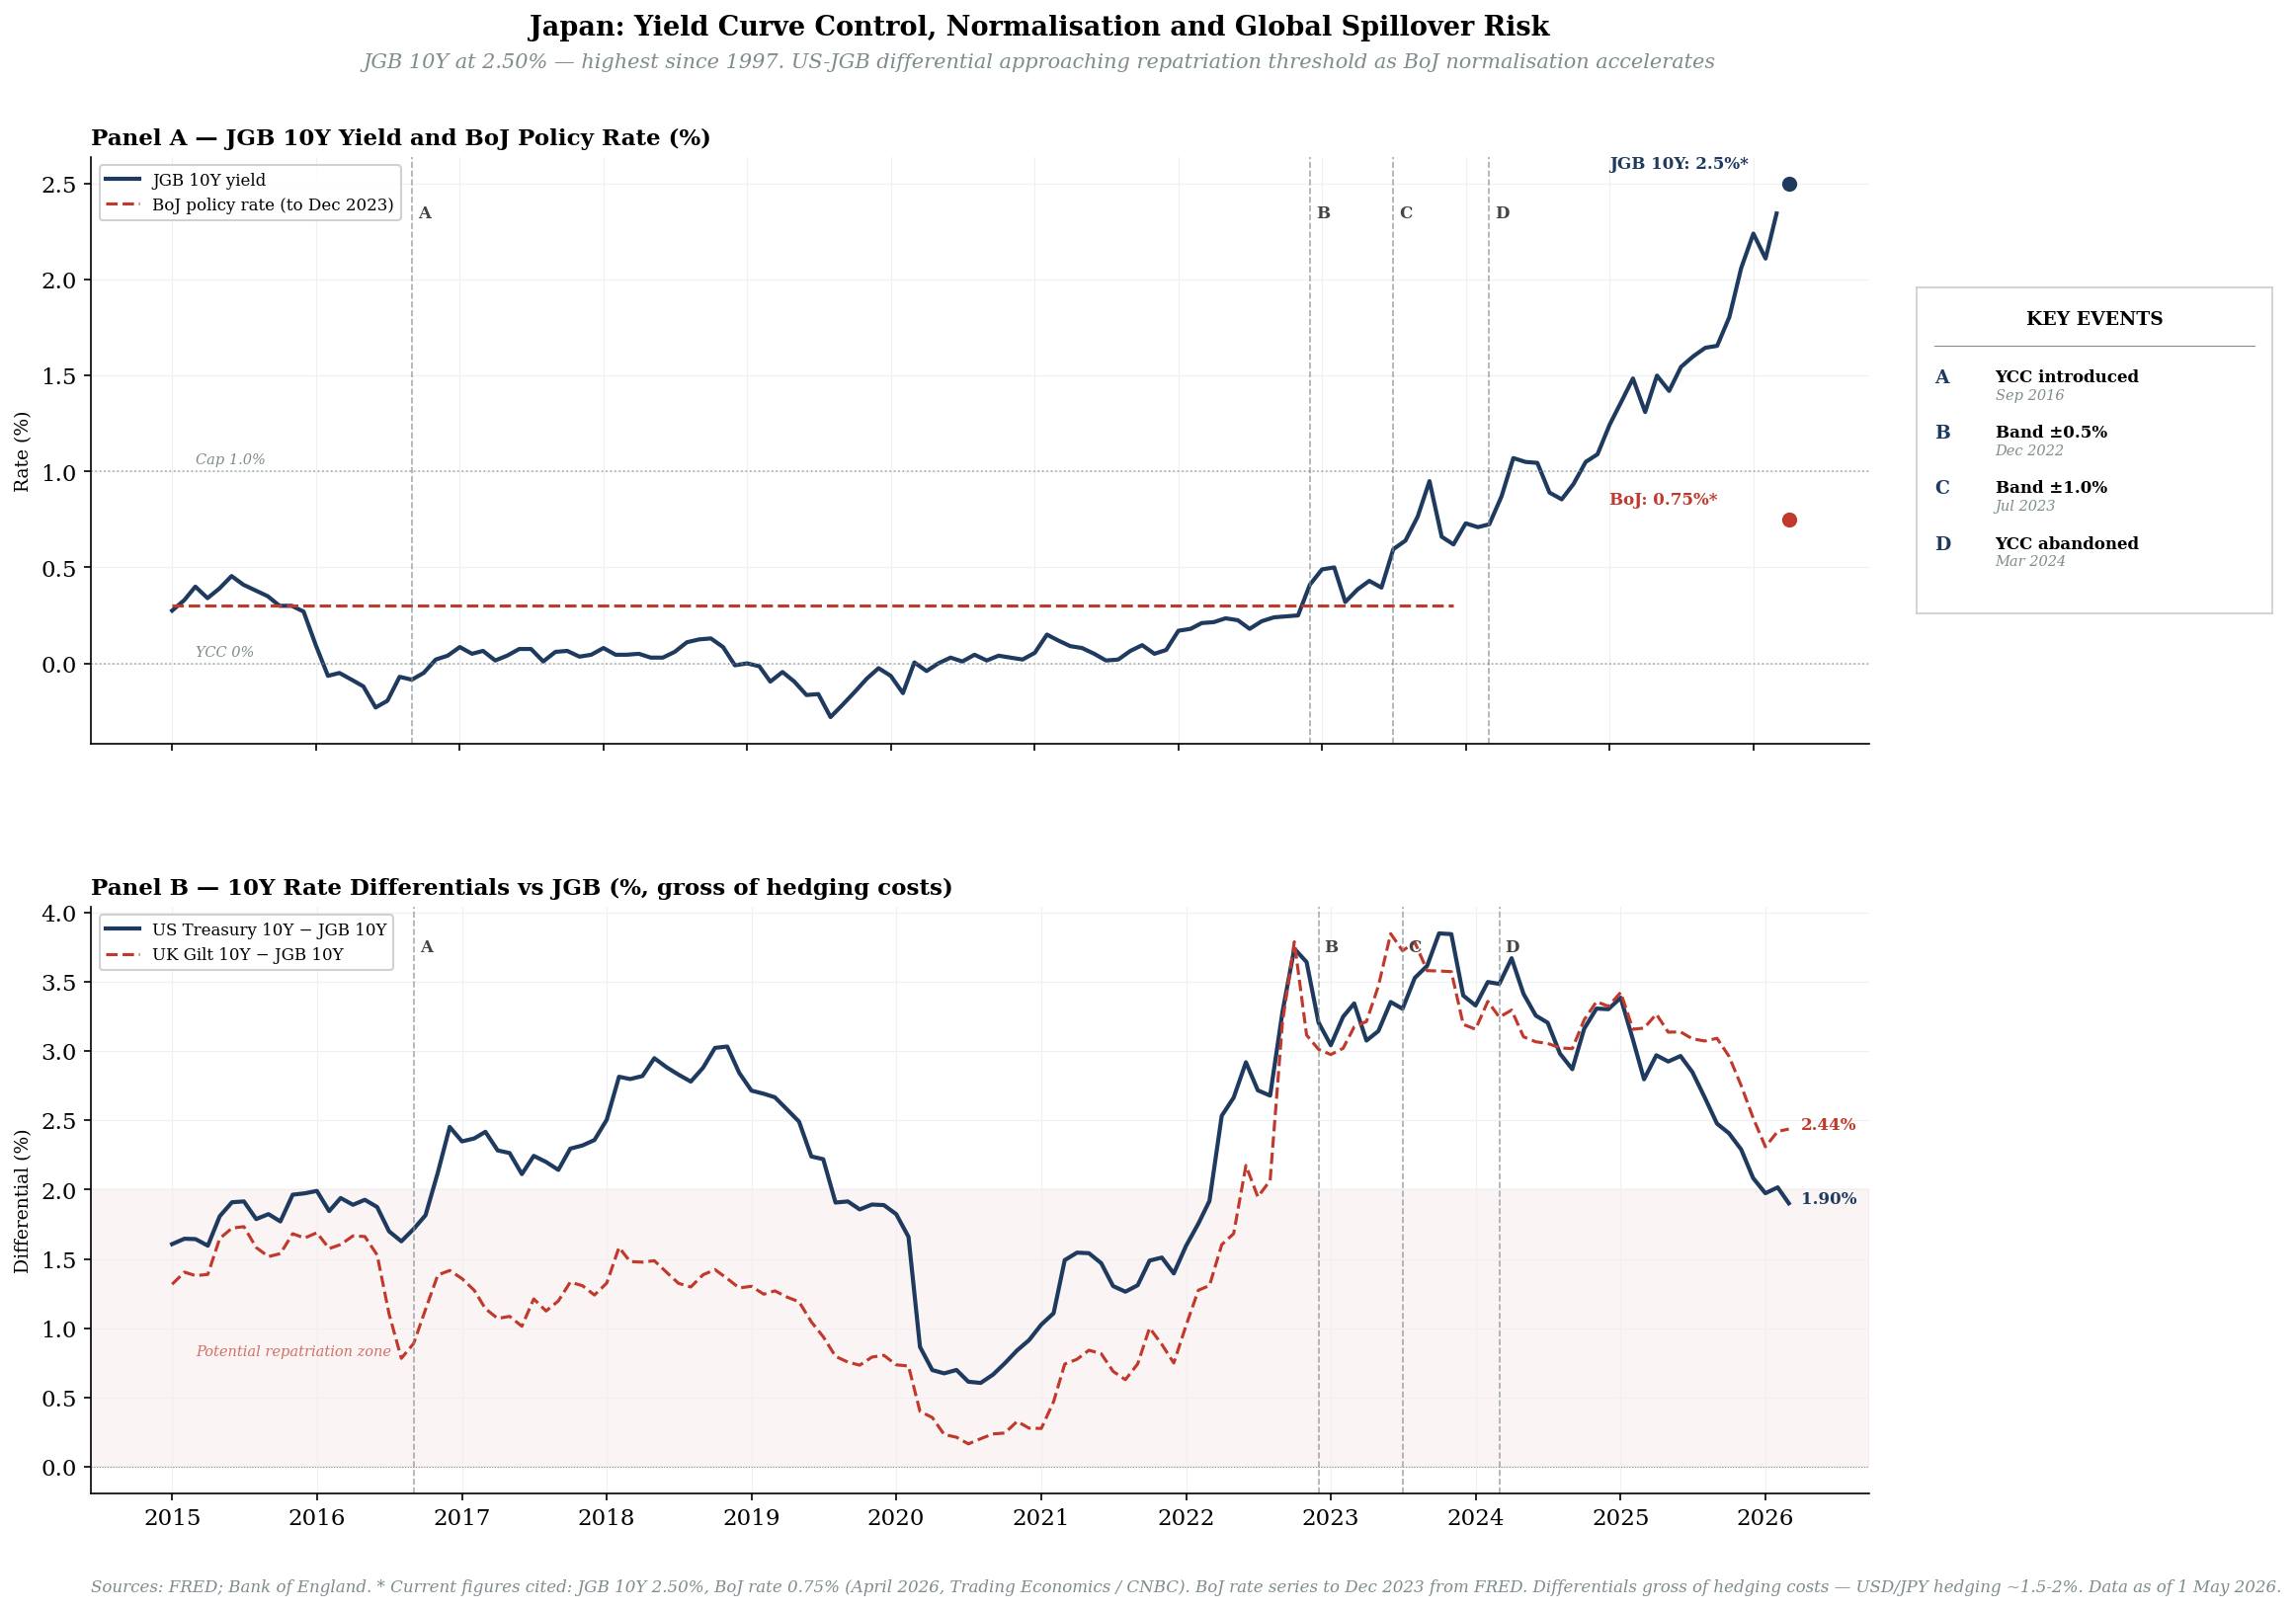

Chart 3 saved — final version

Key numbers:
  JGB 10Y current: 2.5% (highest since 1997)
  BoJ rate current: 0.75%
  US-JGB differential (Mar 2026 data): 1.90%
  Approx current differential (Apr 2026): 1.25% (US 10Y ~3.75% minus JGB 2.50%)


In [34]:
# ============================================================
# Chart 3 — Japan: YCC Normalisation and Rate Differentials
# Panel A — JGB 10Y and BoJ rate
# Panel B — Rate differentials vs US and UK
# Updated: BoJ rate 0.75%, JGB 10Y 2.50% (Apr 2026 cited)
# ============================================================

# Updated current figures
BOJ_CURRENT_RATE  = 0.75
JGB_CURRENT_YIELD = 2.50
JAPAN_CPI_CURRENT = 2.8

fig = plt.figure(figsize=(16, 11))

fig.text(0.45, 0.975,
         "Japan: Yield Curve Control, Normalisation and Global Spillover Risk",
         fontsize=13, fontweight="bold", ha="center")
fig.text(0.45, 0.955,
         "JGB 10Y at 2.50% — highest since 1997. US-JGB differential "
         "approaching repatriation threshold as BoJ normalisation accelerates",
         fontsize=10, ha="center", color=GREY, style="italic")

ax1 = fig.add_axes([0.05, 0.54, 0.75, 0.36])
ax2 = fig.add_axes([0.05, 0.08, 0.75, 0.36])
ax_events = fig.add_axes([0.82, 0.62, 0.15, 0.20])

YCC_EVENTS = [
    ("A", pd.Timestamp("2016-09-01"), "YCC introduced"),
    ("B", pd.Timestamp("2022-12-01"), "Band ±0.5%"),
    ("C", pd.Timestamp("2023-07-01"), "Band ±1.0%"),
    ("D", pd.Timestamp("2024-03-01"), "YCC abandoned"),
]

YCC_EVENT_LABELS = [
    ("A", "YCC introduced", "Sep 2016"),
    ("B", "Band ±0.5%",     "Dec 2022"),
    ("C", "Band ±1.0%",     "Jul 2023"),
    ("D", "YCC abandoned",  "Mar 2024"),
]

# --- Panel A: JGB yield and BoJ rate ---
ax1.plot(jpn_jgb.index.to_numpy(),
         jpn_jgb.to_numpy(),
         color=NAVY, linewidth=2.0, label="JGB 10Y yield")

ax1.plot(jpn_rate.index.to_numpy(),
         jpn_rate.to_numpy(),
         color=RED, linewidth=1.5, linestyle="--",
         label="BoJ policy rate (to Dec 2023)")

# Current figures as reference points
ax1.scatter([pd.Timestamp("2026-04-01")],
            [JGB_CURRENT_YIELD],
            color=NAVY, s=40, zorder=5)
ax1.scatter([pd.Timestamp("2026-04-01")],
            [BOJ_CURRENT_RATE],
            color=RED, s=40, zorder=5)

# Clean annotations — text only, no arrows
ax1.text(pd.Timestamp("2025-01-01"), JGB_CURRENT_YIELD + 0.08,
         f"JGB 10Y: {JGB_CURRENT_YIELD}%*",
         fontsize=8, color=NAVY, fontweight="bold")
ax1.text(pd.Timestamp("2025-01-01"), BOJ_CURRENT_RATE + 0.08,
         f"BoJ: {BOJ_CURRENT_RATE}%*",
         fontsize=8, color=RED, fontweight="bold")

# YCC cap lines — just 0% and 1% to avoid clutter
for level, label in [(0.0, "YCC 0%"), (1.00, "Cap 1.0%")]:
    ax1.axhline(level, color=GREY, linewidth=0.8,
                linestyle=":", alpha=0.7)
    ax1.text(pd.Timestamp("2015-03-01"), level + 0.04,
             label, fontsize=7, color=GREY, style="italic")

ymin1, ymax1 = ax1.get_ylim()
for letter, date, _ in YCC_EVENTS:
    ax1.axvline(date, color=GREY, linewidth=0.8,
                linestyle="--", alpha=0.7)
    ax1.text(date + pd.Timedelta(days=15),
             ymax1 * 0.88, letter,
             fontsize=8, ha="left",
             color="#444444", fontweight="bold")

ax1.set_title("Panel A — JGB 10Y Yield and BoJ Policy Rate (%)",
              fontweight="bold", fontsize=11, loc="left", pad=6)
ax1.set_ylabel("Rate (%)", fontsize=9)
ax1.legend(loc="upper left", framealpha=0.9, fontsize=8)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, color=LGREY, linewidth=0.6)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.set_xticklabels([])

# --- Panel B: Rate differentials ---
ax2.plot(us_jgb_diff.dropna().index.to_numpy(),
         us_jgb_diff.dropna().to_numpy(),
         color=NAVY, linewidth=2.0,
         label="US Treasury 10Y − JGB 10Y")

ax2.plot(uk_jgb_diff.dropna().index.to_numpy(),
         uk_jgb_diff.dropna().to_numpy(),
         color=RED, linewidth=1.5, linestyle="--",
         label="UK Gilt 10Y − JGB 10Y")

ax2.axhline(0, color=GREY, linewidth=0.5, linestyle=":")

# Repatriation zone
ax2.axhspan(0, 2.0, alpha=0.05, color=RED)
ax2.text(pd.Timestamp("2015-03-01"), 0.8,
         "Potential repatriation zone",
         fontsize=7, color=RED, style="italic", alpha=0.7)

# Latest value annotations — clean text, no arrows
latest_date = us_jgb_diff.dropna().index[-1]
ax2.text(latest_date + pd.Timedelta(days=30),
         us_jgb_diff.dropna().iloc[-1],
         f"{us_jgb_diff.dropna().iloc[-1]:.2f}%",
         fontsize=8, color=NAVY, fontweight="bold")
ax2.text(latest_date + pd.Timedelta(days=30),
         uk_jgb_diff.dropna().iloc[-1],
         f"{uk_jgb_diff.dropna().iloc[-1]:.2f}%",
         fontsize=8, color=RED, fontweight="bold")

for letter, date, _ in YCC_EVENTS:
    ax2.axvline(date, color=GREY, linewidth=0.8,
                linestyle="--", alpha=0.7)
    ax2.text(date + pd.Timedelta(days=15),
             ax2.get_ylim()[1] * 0.92, letter,
             fontsize=8, ha="left",
             color="#444444", fontweight="bold")

ax2.set_title("Panel B — 10Y Rate Differentials vs JGB (%, gross of hedging costs)",
              fontweight="bold", fontsize=11, loc="left", pad=6)
ax2.set_ylabel("Differential (%)", fontsize=9)
ax2.legend(loc="upper left", framealpha=0.9, fontsize=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, color=LGREY, linewidth=0.6)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# KEY EVENTS box
ax_events.set_xlim(0, 1)
ax_events.set_ylim(0, 1)
ax_events.set_xticks([])
ax_events.set_yticks([])

for spine in ax_events.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("#cccccc")

ax_events.text(0.5, 0.93, "KEY EVENTS",
               fontsize=9, fontweight="bold",
               ha="center", va="top",
               transform=ax_events.transAxes)

ax_events.axhline(y=0.82, color=GREY,
                  linewidth=0.5, xmin=0.05, xmax=0.95)

spacing = 0.17
for i, (letter, event, date) in enumerate(YCC_EVENT_LABELS):
    y = 0.75 - i * spacing
    ax_events.text(0.05, y, letter,
                   fontsize=9, fontweight="bold",
                   color=NAVY, va="top",
                   transform=ax_events.transAxes)
    ax_events.text(0.22, y, event,
                   fontsize=8, fontweight="bold",
                   va="top",
                   transform=ax_events.transAxes)
    ax_events.text(0.22, y - 0.06, date,
                   fontsize=7, color=GREY,
                   style="italic", va="top",
                   transform=ax_events.transAxes)

fig.text(0.05, 0.02,
         "Sources: FRED; Bank of England. "
         "* Current figures cited: JGB 10Y 2.50%, BoJ rate 0.75% (April 2026, "
         "Trading Economics / CNBC). BoJ rate series to Dec 2023 from FRED. "
         "Differentials gross of hedging costs — USD/JPY hedging ~1.5-2%. "
         "Data as of 1 May 2026.",
         fontsize=8, color=GREY, style="italic")

plt.savefig("../charts/chart3_japan_ycc.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Chart 3 saved — final version")
print(f"\nKey numbers:")
print(f"  JGB 10Y current: {JGB_CURRENT_YIELD}% (highest since 1997)")
print(f"  BoJ rate current: {BOJ_CURRENT_RATE}%")
print(f"  US-JGB differential (Mar 2026 data): "
      f"{us_jgb_diff.dropna().iloc[-1]:.2f}%")
print(f"  Approx current differential (Apr 2026): "
      f"{3.75 - JGB_CURRENT_YIELD:.2f}% "
      f"(US 10Y ~3.75% minus JGB 2.50%)")